In [8]:
import warnings
warnings.filterwarnings('ignore')

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import scipy
import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson
from sklearn.model_selection import train_test_split

In [23]:
data = pd.read_csv('transformed/all_2p_house_races_trainset.csv')
data.head()

,Unnamed: 0,year,state,state_po,special,district,dem,rep,totalvotes,dem_cand,...,cvap_hisp_pct,cvap_black_pct,cvap_natam_pct,no_dem_cand_flag,no_rep_cand_flag,dem_inc_any,rep_inc_any,dem_inc_dummy,rep_inc_dummy,pvi
0,0,2018,Alabama,AL,False,AL-01,89226.0,153228.0,242617,Robert Kennedy Jr,...,2.1,26.4,1.1,False,False,False,True,0,1,-15.715056
1,1,2018,Alabama,AL,False,AL-02,86931.0,138879.0,226230,Tabitha Isner,...,1.9,30.5,0.4,False,False,False,True,0,1,-16.880853
2,2,2018,Alabama,AL,False,AL-03,83996.0,147770.0,231915,Mallory Hagan,...,1.8,25.3,0.3,False,False,False,True,0,1,-17.206974
3,3,2018,Alabama,AL,False,AL-04,46492.0,184255.0,230969,Lee Auman,...,2.2,7.0,0.7,False,False,False,True,0,1,-31.882701
4,4,2018,Alabama,AL,False,AL-05,101388.0,159063.0,260673,Peter Joffrion,...,2.4,17.3,0.7,False,False,False,True,0,1,-18.025364


In [27]:
data = data.set_index(['year', 'district'])
data.head()

Unnamed: 0    state state_po  special       dem       rep  \
year district                                                              
2018 AL-01              0  Alabama       AL    False   89226.0  153228.0   
     AL-02              1  Alabama       AL    False   86931.0  138879.0   
     AL-03              2  Alabama       AL    False   83996.0  147770.0   
     AL-04              3  Alabama       AL    False   46492.0  184255.0   
     AL-05              4  Alabama       AL    False  101388.0  159063.0   

               totalvotes           dem_cand         rep_cand dem_inc rep_inc  \
year district                                                                   
2018 AL-01         242617  Robert Kennedy Jr    Bradley Byrne   False    True   
     AL-02         226230      Tabitha Isner      Martha Roby   False    True   
     AL-03         231915      Mallory Hagan      Mike Rogers   False    True   
     AL-04         230969          Lee Auman  Robert Aderholt   False    True   
     AL-05         260673     Peter Joffrion        Mo Brooks   False    True   

               dem_funds   rep_funds  2party_votes  dem_pct_2p  rep_pct_2p  \
year district                                                                
2018 AL-01      39095.21   343761.59      242454.0   36.801208   63.198792   
     AL-02     501490.57   799289.56      225810.0   38.497409   61.502591   
     AL-03     409309.26    530372.0      231766.0   36.241727   63.758273   
     AL-04      61160.87   468336.48      230747.0   20.148474   79.851526   
     AL-05     553386.53  1216500.38      260451.0   38.927860   61.072140   

               dem_tot_funds  rep_tot_funds   tot_funds  dem_funds_2p_pct  \
year district                                                               
2018 AL-01          39095.21      343761.59   382856.80         10.211445   
     AL-02         501490.57      799289.56  1300780.13         38.553062   
     AL-03         409309.26      530372.00   939681.26         43.558308   
     AL-04          61160.87      468336.48   529497.35         11.550741   
     AL-05         553386.53     1216500.38  1769886.91         31.266773   

               rep_funds_2p_pct  dem_poll_avg  dem_effn  rep_poll_avg  \
year district                                                           
2018 AL-01            89.788555           0.0       0.0           0.0   
     AL-02            61.446938           0.0       0.0           0.0   
     AL-03            56.441692           0.0       0.0           0.0   
     AL-04            88.449259           0.0       0.0           0.0   
     AL-05            68.733227           0.0       0.0           0.0   

               rep_effn  seat_number  prev_lean  prev2_lean  \
year district                                                 
2018 AL-01          0.0            1 -16.192783  -14.281877   
     AL-02          0.0            2 -17.411483  -15.288962   
     AL-03          0.0            3 -18.001999  -14.821901   
     AL-04          0.0            4 -33.277483  -27.698357   
     AL-05          0.0            5 -18.480031  -16.661366   

               generic_ballot_avg  pres_approval_avg  incumbent_pres   ics  \
year district                                                                
2018 AL-01              -7.921785         -10.073704              -1  97.5   
     AL-02              -7.921785         -10.073704              -1  97.5   
     AL-03              -7.921785         -10.073704              -1  97.5   
     AL-04              -7.921785         -10.073704              -1  97.5   
     AL-05              -7.921785         -10.073704              -1  97.5   

               pres_approval_avg_x_incpres  ics_x_incpres  cvap_white_pct  \
year district                                                               
2018 AL-01                       10.073704          -97.5            68.3   
     AL-02                       10.073704          -97.5            65.3   
     AL-03        

In [28]:
data.columns.values

array(['Unnamed: 0', 'state', 'state_po', 'special', 'dem', 'rep',
       'totalvotes', 'dem_cand', 'rep_cand', 'dem_inc', 'rep_inc',
       'dem_funds', 'rep_funds', '2party_votes', 'dem_pct_2p',
       'rep_pct_2p', 'dem_tot_funds', 'rep_tot_funds', 'tot_funds',
       'dem_funds_2p_pct', 'rep_funds_2p_pct', 'dem_poll_avg', 'dem_effn',
       'rep_poll_avg', 'rep_effn', 'seat_number', 'prev_lean',
       'prev2_lean', 'generic_ballot_avg', 'pres_approval_avg',
       'incumbent_pres', 'ics', 'pres_approval_avg_x_incpres',
       'ics_x_incpres', 'cvap_white_pct', 'cvap_asn_pct', 'cvap_hisp_pct',
       'cvap_black_pct', 'cvap_natam_pct', 'no_dem_cand_flag',
       'no_rep_cand_flag', 'dem_inc_any', 'rep_inc_any', 'dem_inc_dummy',
       'rep_inc_dummy', 'pvi'], dtype=object)

In [29]:
data['rep_tot_funds'].isna().any()

np.False_

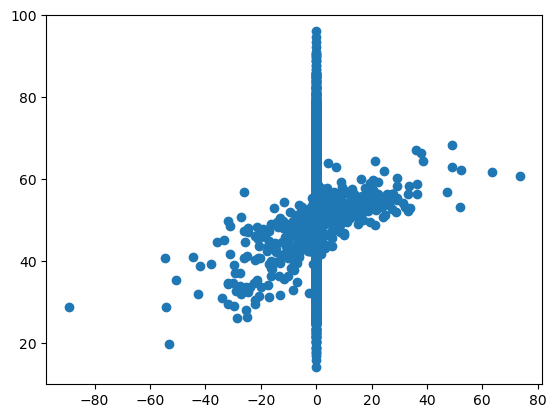

In [30]:
plt.scatter(np.sqrt(data['dem_effn']) * (data['dem_poll_avg'] - data['rep_poll_avg']), data['dem_pct_2p'])

In [31]:
data['dem_funds_2p_pct_sqrd'] = data['dem_funds_2p_pct']**2
data['sqrt_effn'] = np.sqrt(data['dem_effn'])
data['poll_margin'] = data['dem_poll_avg'] - data['rep_poll_avg']
data['effnXmargin'] = data['sqrt_effn'] * data['poll_margin']

## Preliminary Model Check (Frequentist OLS)

In [62]:
y = data['dem_pct_2p']
X = data[['prev_lean', 'prev2_lean', 'generic_ballot_avg',
         'dem_inc_dummy', 'rep_inc_dummy', 'dem_funds_2p_pct_sqrd',
         'cvap_black_pct', 'cvap_hisp_pct', 'cvap_white_pct', 'cvap_asn_pct',
         'effnXmargin']]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [63]:
X.corr()

,prev_lean,prev2_lean,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_funds_2p_pct_sqrd,cvap_black_pct,cvap_hisp_pct,cvap_white_pct,cvap_asn_pct,effnXmargin
prev_lean,1.000000,0.977537,0.046007,0.716935,-0.684671,0.787373,0.405105,0.317538,-0.621862,0.435947,0.173993
prev2_lean,0.977537,1.000000,0.042319,0.718354,-0.680824,0.783436,0.409284,0.364262,-0.656014,0.430103,0.166964
generic_ballot_avg,0.046007,0.042319,1.000000,0.002413,-0.036519,-0.053513,0.034726,0.060106,-0.084167,0.063398,0.072955
dem_inc_dummy,0.716935,0.718354,0.002413,1.000000,-0.731439,0.698774,0.226589,0.254701,-0.438314,0.341751,0.229389
rep_inc_dummy,-0.684671,-0.680824,-0.036519,-0.731439,1.000000,-0.695111,-0.223879,-0.238004,0.417015,-0.311956,-0.242300
dem_funds_2p_pct_sqrd,0.787373,0.783436,-0.053513,0.698774,-0.695111,1.000000,0.226396,0.248488,-0.443772,0.365464,0.151470
cvap_black_pct,0.405105,0.409284,0.034726,0.226589,-0.223879,0.226396,1.000000,-0.103547,-0.498723,-0.100953,0.014796
cvap_hisp_pct,0.317538,0.364262,0.060106,0.254701,-0.238004,0.248488,-0.103547,1.000000,-0.736991,0.215758,0.041641
cvap_white_pct,-0.621862,-0.656014,-0.084167,-0.438314,0.417015,-0.443772,-0.498723,-0.736991,1.000000,-0.431597,-0.058454
cvap_asn_pct,0.435947,0.430103,0.063398,0.341751,-0.311956,0.365464,-0.100953,0.215758,-0.431597,1.000000,0.055076


In [64]:
np.linalg.matrix_rank(X)

np.int64(11)

In [65]:
X_train_const = sm.add_constant(X_train)
model = sm.OLS(y_train, X_train_const)
reg = model.fit(cov_type='HC1')
reg.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             dem_pct_2p   R-squared:                       0.973
Model:                            OLS   Adj. R-squared:                  0.973
Method:                 Least Squares   F-statistic:                     4295.
Date:                Thu, 18 Jun 2026   Prob (F-statistic):               0.00
Time:                        16:50:51   Log-Likelihood:                -2583.5
No. Observations:                1072   AIC:                             5191.
Df Residuals:                    1060   BIC:                             5251.
Df Model:                          11                                         
Covariance Type:                  HC1                                         
=========================================================================================
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                    56.9940      2.887     19.741      0.000      51.336      62.653
prev_lean                 0.6027      0.035     17.221      0.000       0.534       0.671
prev2_lean                0.2947      0.034      8.768      0.000       0.229       0.361
generic_ballot_avg       -0.3555      0.022    -15.962      0.000      -0.399      -0.312
dem_inc_dummy             0.7503      0.313      2.400      0.016       0.138       1.363
rep_inc_dummy            -1.5825      0.307     -5.148      0.000      -2.185      -0.980
dem_funds_2p_pct_sqrd     0.0004   4.74e-05      9.320      0.000       0.000       0.001
cvap_black_pct           -0.0946      0.030     -3.193      0.001      -0.153      -0.037
cvap_hisp_pct            -0.1196      0.031     -3.914      0.000      -0.179      -0.060
cvap_white_pct           -0.0837      0.029     -2.863      0.004      -0.141      -0.026
cvap_asn_pct             -0.1080      0.032     -3.344      0.001      -0.171      -0.045
effnXmargin               0.0151      0.009      1.608      0.108      -0.003       0.034
==============================================================================
Omnibus:                       56.941   Durbin-Watson:                   1.980
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              131.263
Skew:                           0.302   Prob(JB):                     3.14e-29
Kurtosis:                       4.605   Cond. No.                     2.18e+05
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC1)
[2] The condition number is large, 2.18e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [52]:
y_test_hat = reg.predict(sm.add_constant(X_test))
X_test['residuals'] = y_test_hat - y_test
np.mean((y_test - y_test_hat)**2), np.mean(abs(y_test - y_test_hat))

(np.float64(6.087010419874171), np.float64(1.9372421424685715))

In [53]:
y_test - y_test_hat

year  district
2020  IL-15      -1.544257
2018  TX-31       5.173558
      MD-07      -1.652631
      IN-04      -0.361365
2022  IN-01       1.011373
                    ...   
2024  WI-03       3.179877
2020  WA-05      -4.516728
2018  WA-04      -1.467785
2024  NC-11      -0.747938
2018  IL-13       0.495656
Length: 528, dtype: float64

In [54]:
X_test.corr()

,prev_lean,prev2_lean,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_funds_2p_pct_sqrd,cvap_black_pct,cvap_hisp_pct,cvap_white_pct,cvap_asn_pct,poll_margin,residuals
prev_lean,1.000000,0.975298,-0.015183,0.723552,-0.702287,0.802885,0.374687,0.318338,-0.626596,0.451210,0.221249,-0.041046
prev2_lean,0.975298,1.000000,-0.018983,0.723818,-0.697720,0.800220,0.376993,0.371490,-0.663351,0.444282,0.210107,-0.018801
generic_ballot_avg,-0.015183,-0.018983,1.000000,-0.078807,0.056680,-0.115703,0.034258,0.022229,-0.049458,0.029564,0.091299,0.012453
dem_inc_dummy,0.723552,0.723818,-0.078807,1.000000,-0.750451,0.692654,0.226071,0.268289,-0.469806,0.375556,0.260512,-0.010342
rep_inc_dummy,-0.702287,-0.697720,0.056680,-0.750451,1.000000,-0.714927,-0.208307,-0.242225,0.427525,-0.330371,-0.293741,-0.028972
dem_funds_2p_pct_sqrd,0.802885,0.800220,-0.115703,0.692654,-0.714927,1.000000,0.205422,0.263520,-0.469658,0.397902,0.198974,-0.026833
cvap_black_pct,0.374687,0.376993,0.034258,0.226071,-0.208307,0.205422,1.000000,-0.134944,-0.467682,-0.137737,0.025605,-0.072231
cvap_hisp_pct,0.318338,0.371490,0.022229,0.268289,-0.242225,0.263520,-0.134944,1.000000,-0.734767,0.243761,0.050922,0.039160
cvap_white_pct,-0.626596,-0.663351,-0.049458,-0.469806,0.427525,-0.469658,-0.467682,-0.734767,1.000000,-0.448291,-0.079985,-0.004913
cvap_asn_pct,0.451210,0.444282,0.029564,0.375556,-0.330371,0.397902,-0.137737,0.243761,-0.448291,1.000000,0.060755,0.063061


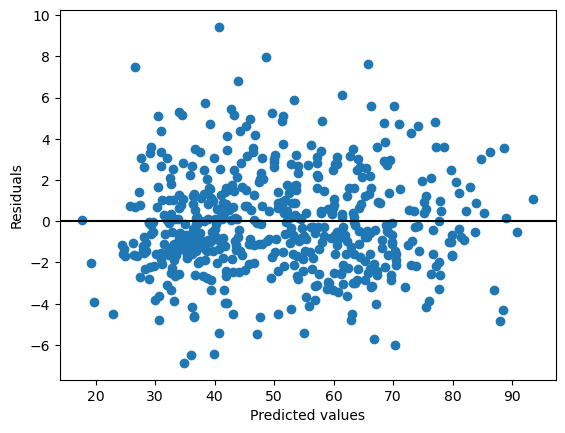

In [55]:
# Residuals
plt.scatter(y_test_hat, y_test - y_test_hat)
plt.axhline(0, color='black')
plt.xlabel('Predicted values')
plt.ylabel('Residuals');

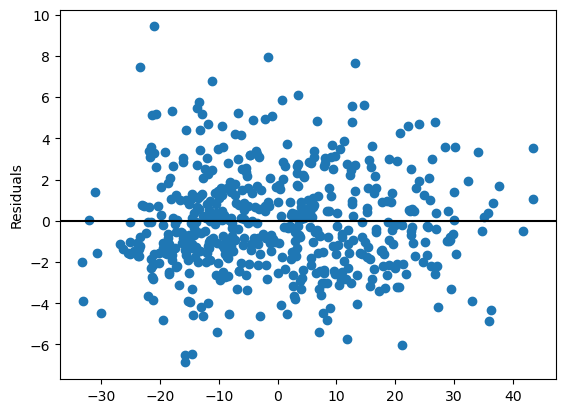

In [56]:
# Residuals
plt.scatter(X_test['prev2_lean'], y_test - y_test_hat)
plt.axhline(0, color='black')
plt.ylabel('Residuals');

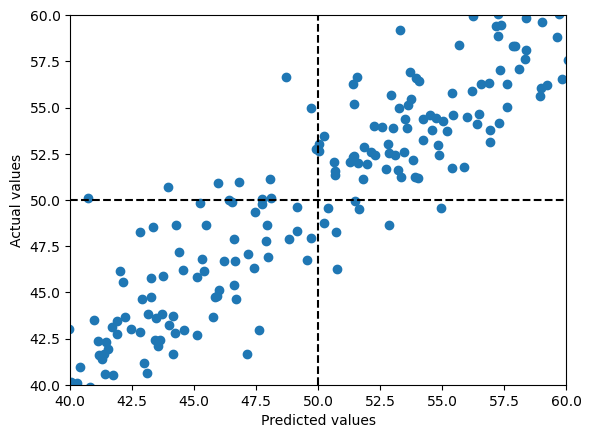

In [57]:
# Actual vs predicted
plt.scatter(y_test_hat, y_test)
plt.axhline(50, color='black', linestyle='--')
plt.axvline(50, color='black', linestyle='--')
plt.xlim(40, 60)
plt.ylim(40, 60)
plt.xlabel('Predicted values')
plt.ylabel('Actual values');

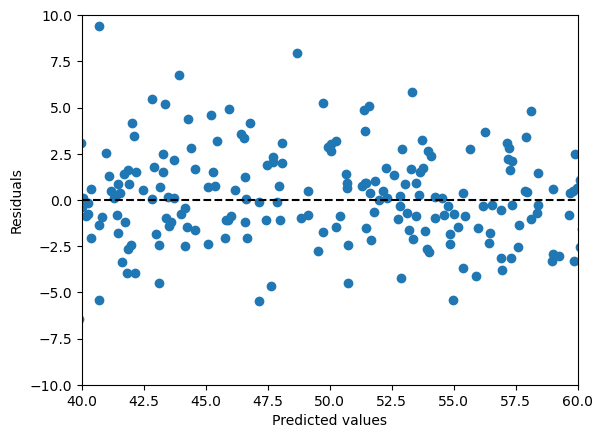

In [58]:
# Actual vs residuals
plt.scatter(y_test_hat, y_test - y_test_hat)
plt.axhline(0, color='black', linestyle='--')
plt.xlim(40, 60)
plt.ylim(-10, 10)
plt.xlabel('Predicted values')
plt.ylabel('Residuals');

In [59]:
resid = pd.DataFrame(y_test_hat - y_test)
resid = resid.reset_index().rename({0: 'resid'}, axis=1)
resid.head()

,year,district,resid
0,2020,IL-15,1.544257
1,2018,TX-31,-5.173558
2,2018,MD-07,1.652631
3,2018,IN-04,0.361365
4,2022,IN-01,-1.011373


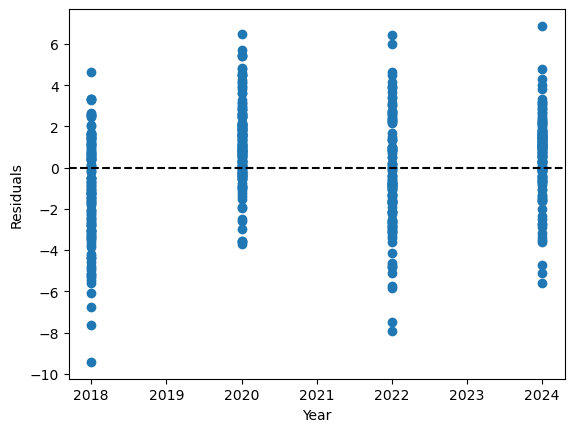

In [60]:
plt.scatter(resid['year'], resid['resid'])
plt.xlabel('Year')
plt.ylabel('Residuals')
plt.axhline(0, color='black', linestyle='--');

In [61]:
durbin_watson(reg.resid)

np.float64(1.9784027336335988)